In [33]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

In [34]:
# ── loading the data set ──────────────────────────────────
DATA_DIR = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"

df = pd.read_csv(f"{DATA_DIR}/Data_Entry_2017.csv")

print(f"✓ Dataset chargé : {len(df):,} lignes")
print(f"✓ Colonnes : {df.columns.tolist()}")
print(f"\n{df.head(3)}")

✓ Dataset chargé : 112,120 lignes
✓ Colonnes : ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']

        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   

   Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
0           58              M            PA                 2682     2749   
1           58              M            PA                 2894     2729   
2           58              M            PA                 2500     2048   

   OriginalImagePixelSpacing[x     y]  Unnamed: 11  
0                        0.143  0.143          NaN  
1                        0.143  0.143          Na

In [35]:
df['Finding Labels'].value_counts()
all_labels = []
for i in df['Finding Labels']:
    disease = i.split('|')
    all_labels.extend(disease)

In [36]:
# Step 2 - create dataframe with different name
data_labels = pd.Series(all_labels).value_counts().to_frame()

# Step 3 - extract numpy arrays
diseases = np.array(data_labels.index)
counts   = np.array(data_labels['count']).flatten()

print(diseases)
print(counts)

['No Finding' 'Infiltration' 'Effusion' 'Atelectasis' 'Nodule' 'Mass'
 'Pneumothorax' 'Consolidation' 'Pleural_Thickening' 'Cardiomegaly'
 'Emphysema' 'Edema' 'Fibrosis' 'Pneumonia' 'Hernia']
[60361 19894 13317 11559  6331  5782  5302  4667  3385  2776  2516  2303
  1686  1431   227]


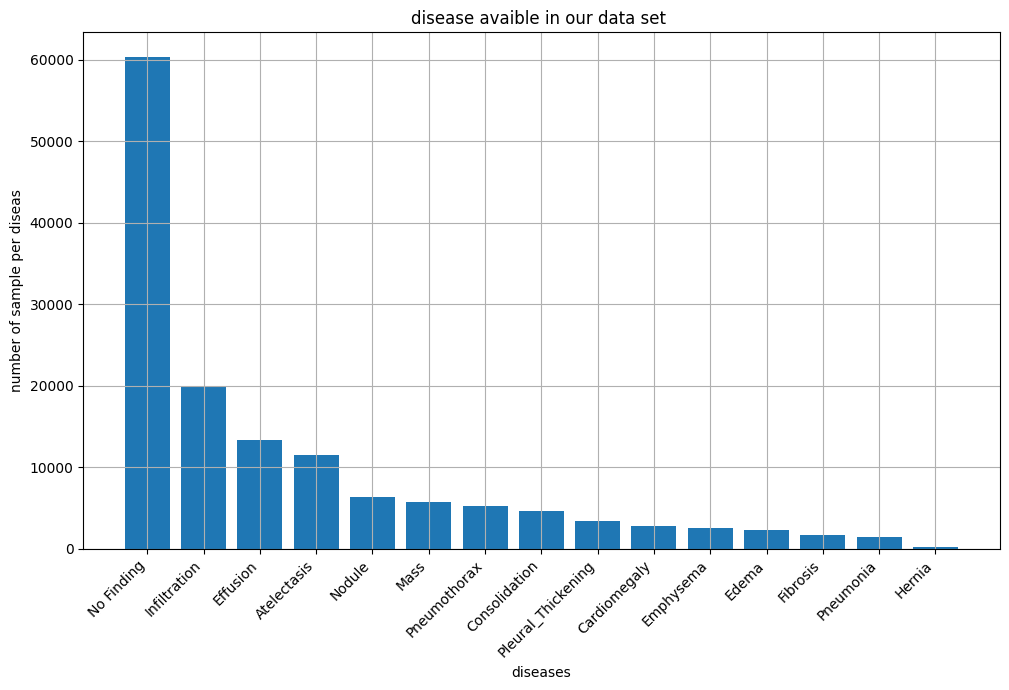

In [37]:
# ploting bar of each diseas
plt.figure(figsize=(10,7))
plt.title("disease avaible in our data set ")
plt.bar(diseases,counts.flatten())
plt.xlabel('diseases')
plt.xticks(rotation=45, ha='right')  # ← rotate 45 degrees
plt.tight_layout()
plt.ylabel('number of sample per diseas')
plt.grid('True')

In [38]:

df.groupby(['Patient ID']).count()

,Image Index,Finding Labels,Follow-up #,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
Patient ID,,,,,,,,,,,
1,3,3,3,3,3,3,3,3,3,3,0
2,1,1,1,1,1,1,1,1,1,1,0
3,8,8,8,8,8,8,8,8,8,8,0
4,1,1,1,1,1,1,1,1,1,1,0
5,8,8,8,8,8,8,8,8,8,8,0
...,...,...,...,...,...,...,...,...,...,...,...
30801,2,2,2,2,2,2,2,2,2,2,0
30802,1,1,1,1,1,1,1,1,1,1,0
30803,1,1,1,1,1,1,1,1,1,1,0


In [39]:

data_labels['count']
# Most frequent disease
print("most frequence" , data_labels[data_labels['count'] == data_labels['count'].max()])
# less frequence diseas
print("less frequence diseas " , data_labels[data_labels['count'] == data_labels['count'].min()])



most frequence             count
No Finding  60361
less frequence diseas          count
Hernia    227


In [40]:
sorted_df = data_labels.sort_values(by='count')
print("Sorted by Age:\n", sorted_df)

Sorted by Age:
                     count
Hernia                227
Pneumonia            1431
Fibrosis             1686
Edema                2303
Emphysema            2516
Cardiomegaly         2776
Pleural_Thickening   3385
Consolidation        4667
Pneumothorax         5302
Mass                 5782
Nodule               6331
Atelectasis         11559
Effusion            13317
Infiltration        19894
No Finding          60361


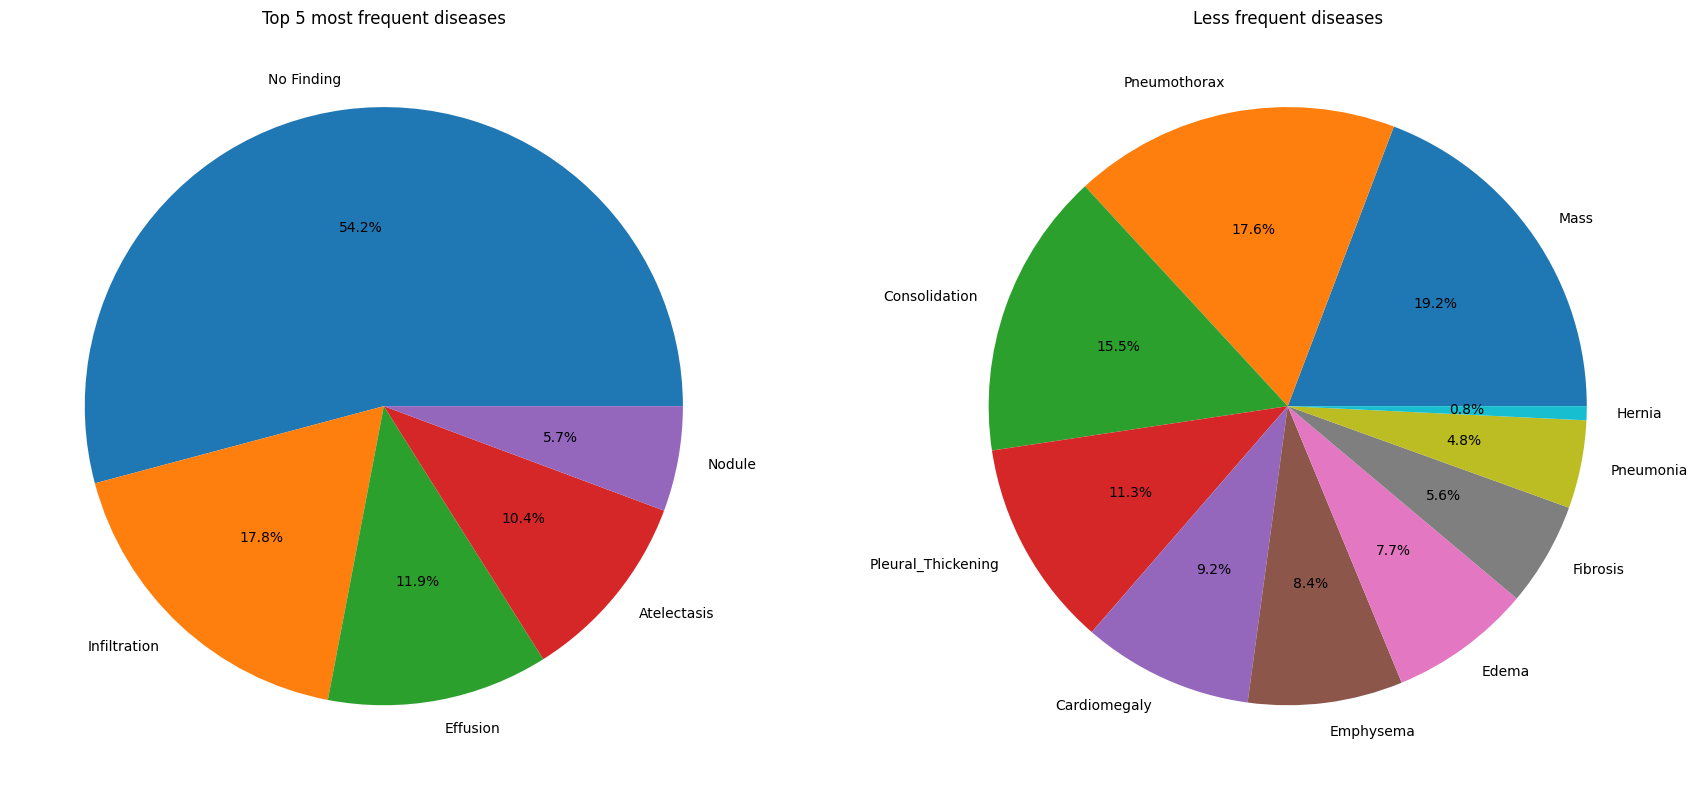

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Group 1 - Top 5 most frequent
axes[0].pie(
    counts[:5],
    labels=diseases[:5],
    autopct='%1.1f%%'
)
axes[0].set_title('Top 5 most frequent diseases')

# Group 2 - Bottom 10 least frequent
axes[1].pie(
    counts[5:],
    labels=diseases[5:],
    autopct='%1.1f%%'
)
axes[1].set_title('Less frequent diseases')

plt.tight_layout()
plt.show()

In [42]:
# How many images per patient ?
df.groupby('Patient ID').count()


,Image Index,Finding Labels,Follow-up #,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
Patient ID,,,,,,,,,,,
1,3,3,3,3,3,3,3,3,3,3,0
2,1,1,1,1,1,1,1,1,1,1,0
3,8,8,8,8,8,8,8,8,8,8,0
4,1,1,1,1,1,1,1,1,1,1,0
5,8,8,8,8,8,8,8,8,8,8,0
...,...,...,...,...,...,...,...,...,...,...,...
30801,2,2,2,2,2,2,2,2,2,2,0
30802,1,1,1,1,1,1,1,1,1,1,0
30803,1,1,1,1,1,1,1,1,1,1,0


In [43]:
images_per_patient = df.groupby('Patient ID')['Image Index'].count()
print(f"Average images per patient : {images_per_patient.mean():.2f}")
print(f"Max images per patient     : {images_per_patient.max()}")
print(f"Min images per patient     : {images_per_patient.min()}")

Average images per patient : 3.64
Max images per patient     : 184
Min images per patient     : 1


In [44]:
# Find which patient has 184 images
images_per_patient = df.groupby('Patient ID')['Image Index'].count()
worst_patient = images_per_patient.idxmax()
print(f"Patient with most images : {worst_patient}")
print(f"Number of images         : {images_per_patient.max()}")

# See their diseases
print(df[df['Patient ID'] == worst_patient]['Finding Labels'].value_counts())

Patient with most images : 10007
Number of images         : 184
Finding Labels
No Finding                                              45
Effusion                                                21
Effusion|Infiltration                                   13
Pleural_Thickening                                      12
Consolidation                                           11
Infiltration                                            11
Atelectasis|Consolidation                                5
Atelectasis|Consolidation|Effusion|Infiltration          5
Cardiomegaly                                             4
Infiltration|Mass                                        4
Cardiomegaly|Effusion                                    4
Effusion|Infiltration|Mass                               3
Effusion|Infiltration|Pleural_Thickening                 3
Edema|Infiltration                                       3
Infiltration|Pleural_Thickening                          3
Edema|Pleural_Thickening            

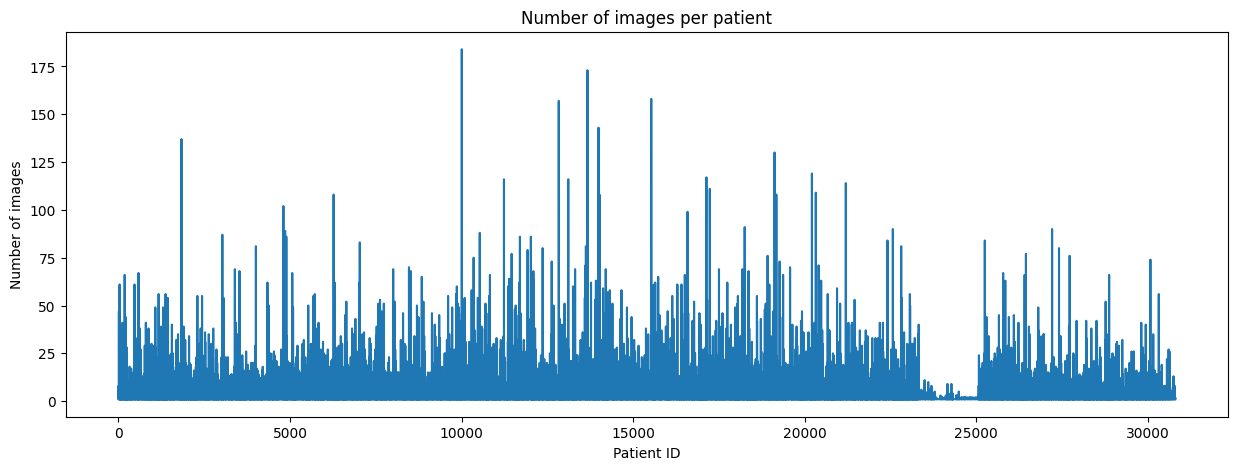

In [45]:
plt.figure(figsize=(15, 5))
plt.plot(images_per_patient.index,   # Patient ID
         images_per_patient.values)  # nombre d'images
plt.title('Number of images per patient')
plt.xlabel('Patient ID')
plt.ylabel('Number of images')
plt.show()

In [46]:
from sklearn.model_selection import train_test_split

# Get unique patients
unique_patients = df['Patient ID'].unique()

# Split patients not images !
train_patients, test_patients = train_test_split(
    unique_patients, 
    test_size=0.1, 
    random_state=42
)

# Get images belonging to each group
train_df = df[df['Patient ID'].isin(train_patients)].copy()
test_df  = df[df['Patient ID'].isin(test_patients)].copy()

print(f"Train images : {len(train_df):,}")
print(f"Test images  : {len(test_df):,}")

# Verify no patient leakage
overlap = set(train_patients) & set(test_patients)
print(f"Patient overlap : {len(overlap)}")  # Must be 0 !

Train images : 101,170
Test images  : 10,950
Patient overlap : 0


In [47]:
train_df.columns.tolist()


['Image Index',
 'Finding Labels',
 'Follow-up #',
 'Patient ID',
 'Patient Age',
 'Patient Gender',
 'View Position',
 'OriginalImage[Width',
 'Height]',
 'OriginalImagePixelSpacing[x',
 'y]',
 'Unnamed: 11']

In [48]:
print(f"Train images : {len(train_df):,}")
print(f"Test images  : {len(test_df):,}")
print(f"Train patients : {train_df['Patient ID'].nunique():,}")
print(f"Test patients  : {test_df['Patient ID'].nunique():,}")

Train images : 101,170
Test images  : 10,950
Train patients : 27,724
Test patients  : 3,081


In [49]:
train_df['Finding Labels'].value_counts()

Finding Labels
No Finding                                                                                        54416
Infiltration                                                                                       8616
Atelectasis                                                                                        3768
Effusion                                                                                           3583
Nodule                                                                                             2446
                                                                                                  ...  
Atelectasis|Consolidation|Edema|Effusion|Infiltration|Mass|Nodule|Pleural_Thickening|Pneumonia        1
Atelectasis|Cardiomegaly|Effusion|Infiltration|Pneumonia                                              1
Atelectasis|Edema|Mass|Pleural_Thickening                                                             1
Atelectasis|Hernia|Pleural_Thickening            

In [50]:
train_df['binary_label'] = train_df['Finding Labels'].apply(
    lambda x: 0 if x == 'No Finding' else 1
)

In [51]:
train_df.columns.tolist()

['Image Index',
 'Finding Labels',
 'Follow-up #',
 'Patient ID',
 'Patient Age',
 'Patient Gender',
 'View Position',
 'OriginalImage[Width',
 'Height]',
 'OriginalImagePixelSpacing[x',
 'y]',
 'Unnamed: 11',
 'binary_label']

In [52]:
!ls /kaggle/input/datasets/organizations/nih-chest-xrays/data/ # voir le contenu de folder

ARXIV_V5_CHESTXRAY.pdf	images_002  images_007	images_012
BBox_List_2017.csv	images_003  images_008	LOG_CHESTXRAY.pdf
Data_Entry_2017.csv	images_004  images_009	README_CHESTXRAY.pdf
FAQ_CHESTXRAY.pdf	images_005  images_010	test_list.txt
images_001		images_006  images_011	train_val_list.txt


In [53]:
# crrer un mapping entre les images et le data entry
import os
chemin = os.path.join(DATA_DIR, "images_001", "images")



In [54]:
import os

# Build dictionary ONCE : filename → full path
image_paths = {}
for i in range(1, 13):
    folder = os.path.join(DATA_DIR, f"images_{i:03d}", "images")
    if os.path.exists(folder):
        for fname in os.listdir(folder):
            image_paths[fname] = os.path.join(folder, fname)

print(f"Total images indexed : {len(image_paths):,}")


train_df['image_path'] = train_df['Image Index'].map(image_paths)
test_df['image_path']  = test_df['Image Index'].map(image_paths)

print(f"Train paths found : {train_df['image_path'].notna().sum():,}")
print(f"Test paths found  : {test_df['image_path'].notna().sum():,}")

Total images indexed : 112,120
Train paths found : 101,170
Test paths found  : 10,950


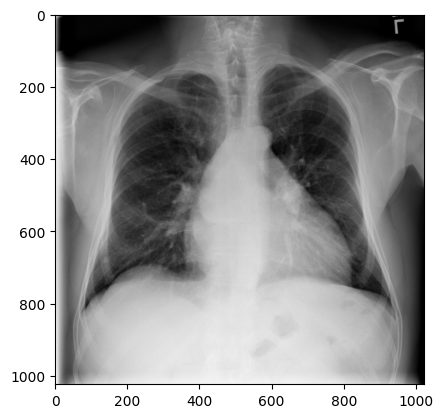

In [55]:
import matplotlib.image as mpimg # try printing image from data set 
sample = train_df.iloc[0]
image = mpimg.imread(sample['image_path'])
plt.imshow(image , cmap = 'gray')
plt.show(True)

In [56]:
# reshape images for Efficent net model
import tensorflow as tf
# create data set from bianry labels
dataset = tf.data.Dataset.from_tensor_slices((train_df['image_path'], train_df['binary_label']))

def load_image(path, label):
    # étape 1 : tf.io.read_file()
    image = tf.io.read_file(path)
    # étape 2 : tf.image.decode_png()
    image = tf.image.decode_png(image, channels=3)
    # étape 3 : tf.image.resize()
    image = tf.image.resize(image , [224 , 224])
    # étape 4 : tf.cast() + / 255.0
    image = tf.cast(image , tf.float32)
    image = image / 255 # for normalization
    return image, label

dataset = dataset.map(load_image)

In [57]:
# verfiy that images are charged ok
for image , label in dataset.take(10):
    print(image.shape)
    print(label)

(224, 224, 3)
tf.Tensor(1, shape=(), dtype=int64)
(224, 224, 3)
tf.Tensor(1, shape=(), dtype=int64)
(224, 224, 3)
tf.Tensor(1, shape=(), dtype=int64)
(224, 224, 3)
tf.Tensor(0, shape=(), dtype=int64)
(224, 224, 3)
tf.Tensor(1, shape=(), dtype=int64)
(224, 224, 3)
tf.Tensor(1, shape=(), dtype=int64)
(224, 224, 3)
tf.Tensor(1, shape=(), dtype=int64)
(224, 224, 3)
tf.Tensor(1, shape=(), dtype=int64)
(224, 224, 3)
tf.Tensor(1, shape=(), dtype=int64)
(224, 224, 3)
tf.Tensor(1, shape=(), dtype=int64)


In [65]:
# shuffling the data
dataset = dataset.shuffle(buffer_size = 1000)
# select number of unique batc
dataset = dataset.batch(batch_size = 64)
# use prefectch methode to solve bottlneck problem
dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)


In [80]:
# loading Efficent net model and setup it
model_eff = tf.keras.Sequential([
    tf.keras.applications.EfficientNetB0(weights = 'imagenet',input_shape=(224, 224, 3) , include_top=False),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1 , activation = 'sigmoid'),
]
)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [85]:
# create model
model_eff.compile(
    optimizer = 'adam',
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy', tf.keras.metrics.AUC(name='auroc')]
)